# Modelado de precios de autos usados

Este notebook entrena y evalúa modelos para estimar `price` en el conjunto *Regression of Used Car Prices* (Playground Series S4E9). El conjunto de prueba se reserva antes de aprender cualquier transformación. Las extracciones de `engine` y `transmission`, la imputación, la codificación y el escalamiento quedan dentro de un `Pipeline` completo, ajustado solo con entrenamiento. Las métricas finales se calculan en dólares y sobre el test reservado.

In [ ]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

RANDOM_STATE = 42

# Resuelve la ruta si el kernel inicia en notebooks, fase-1 o la raíz del proyecto.
CURRENT_DIR = Path.cwd()
if (CURRENT_DIR / "features.py").exists():
    FASE_DIR = CURRENT_DIR
elif (CURRENT_DIR / "fase-1" / "features.py").exists():
    FASE_DIR = CURRENT_DIR / "fase-1"
elif (CURRENT_DIR.parent / "features.py").exists():
    FASE_DIR = CURRENT_DIR.parent
else:
    raise FileNotFoundError("No se encontró fase-1/features.py desde el directorio actual.")

if str(FASE_DIR) not in sys.path:
    sys.path.insert(0, str(FASE_DIR))

from features import (
    build_preprocessor,
    extract_engine_features,
    extract_transmission_features,
)

DATA_PATH = FASE_DIR / "data" / "train.csv"
df = pd.read_csv(DATA_PATH)
assert "price" in df.columns, "El CSV debe contener la variable objetivo 'price'."
assert df["price"].notna().all(), "Hay valores ausentes en el objetivo price."

X = df.drop(columns=["id", "price"])
y = df["price"].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Datos: {df.shape[0]:,} filas y {df.shape[1]} columnas")
print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")
print(f"RANDOM_STATE: {RANDOM_STATE}")
print(f"Precio train: ${y_train.min():,.0f} a ${y_train.max():,.0f}")

Matplotlib is building the font cache; this may take a moment.


Datos: 188,533 filas y 13 columnas
Train: 150,826 filas | Test: 37,707 filas
RANDOM_STATE: 42
Precio train: $2,000 a $2,954,083


La partición contiene 80% de las observaciones en entrenamiento y 20% en test. `id` se excluyó por ser un identificador y `price` se separó como objetivo. A partir de aquí, el test se reserva para la evaluación final; cualquier estadística aprendida por las transformaciones se estima dentro del pipeline usando exclusivamente entrenamiento.

## Métricas de evaluación y modelos baseline

La competición evalúa con RMSE, que penaliza con mayor intensidad los errores grandes: el resultado se expresa en dólares y un error de 20.000 dólares pesa más que dos errores de 10.000 dólares. Lo acompañaremos con MAE, el error absoluto promedio en dólares, más fácil de interpretar y menos sensible a extremos, y con R², una medida adimensional de mejora respecto a predecir la media (puede ser negativa). Ninguna métrica resume por sí sola todos los aspectos de la calidad del modelo.

Primero calculamos dos referencias sin características: predecir siempre la media o siempre la mediana del precio de entrenamiento. Se evalúan en el test reservado; sirven para comprobar si el modelo aprende señal útil, no como candidatos de despliegue.

In [ ]:
def calcular_metricas(y_real, y_pred):
    return {
        "RMSE ($)": mean_squared_error(y_real, y_pred) ** 0.5,
        "MAE ($)": mean_absolute_error(y_real, y_pred),
        "R²": r2_score(y_real, y_pred),
    }

baseline_rows = []
for strategy in ["mean", "median"]:
    baseline = DummyRegressor(strategy=strategy)
    baseline.fit(X_train, y_train)
    predictions = baseline.predict(X_test)
    baseline_rows.append({"Modelo": f"Dummy ({strategy})", **calcular_metricas(y_test, predictions)})

baseline_results = pd.DataFrame(baseline_rows).set_index("Modelo")
display(baseline_results.round({"RMSE ($)": 0, "MAE ($)": 0, "R²": 4}))

,RMSE ($),MAE ($),R²
Modelo,,,
Dummy (mean),74573.0,29087.0,-0.0000
Dummy (median),75703.0,26548.0,-0.0305


Como es esperable, ambos baselines tienen R² cercano a cero o negativo: una constante no captura las diferencias entre vehículos. La media obtiene menor RMSE y la mediana menor MAE, ilustrando la distinta sensibilidad de ambas métricas a errores grandes. Estos valores son la referencia que el modelo con características debe superar.

## Modelo predictivo y validación cruzada

Elegimos un bosque aleatorio porque puede modelar relaciones no lineales e interacciones entre atributos del vehículo sin exigir una forma funcional previa. Su costo se controla con 40 árboles, profundidad máxima de 20, mínimo de tres observaciones por hoja y ejecución paralela. Se reutiliza `build_preprocessor()` junto con las extracciones deterministas de `engine` y `transmission`, todo dentro del mismo `Pipeline`; aunque el escalado no es necesario para árboles, se conserva la definición común del módulo. Mantenemos `price` sin transformación logarítmica para optimizar y reportar las métricas en dólares directamente.

La validación cruzada de cinco folds se realiza únicamente dentro de `X_train, y_train`. Se presentan RMSE y MAE por fold en dólares, y R² sin unidad, junto con promedio y desviación estándar; `cross_validate` clona y ajusta el pipeline de forma independiente en cada fold.

In [5]:
pipeline = Pipeline(
    steps=[
        ("engine_features", FunctionTransformer(extract_engine_features, validate=False)),
        ("transmission_features", FunctionTransformer(extract_transmission_features, validate=False)),
        ("preprocessor", build_preprocessor()),
        (
            "model",
            RandomForestRegressor(
                n_estimators=40,
                max_depth=20,
                min_samples_leaf=3,
                max_features=0.7,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    },
    n_jobs=1,
    return_train_score=False,
)

cv_results = pd.DataFrame(
    {
        "RMSE ($)": -cv_scores["test_rmse"],
        "MAE ($)": -cv_scores["test_mae"],
        "R²": cv_scores["test_r2"],
    },
    index=[f"Fold {fold}" for fold in range(1, 6)],
)
cv_summary = pd.DataFrame({"Media": cv_results.mean(), "Desviación estándar": cv_results.std()})
cv_summary_display = cv_summary.copy()
cv_summary_display.loc[["RMSE ($)", "MAE ($)"]] = cv_summary_display.loc[["RMSE ($)", "MAE ($)"]].round(0)
cv_summary_display.loc["R²"] = cv_summary_display.loc["R²"].round(4)
print("Resultados por fold:")
display(cv_results.round({"RMSE ($)": 0, "MAE ($)": 0, "R²": 4}))
print("Resumen de validación cruzada:")
display(cv_summary_display)

# Después de la validación, ajustamos el pipeline definitivo con todo el conjunto train.
pipeline.fit(X_train, y_train)
print("Pipeline final ajustado con X_train; X_test sigue reservado para la evaluación final.")

Resultados por fold:


,RMSE ($),MAE ($),R²
Fold 1,64782.0,19791.0,0.1192
Fold 2,77066.0,20504.0,0.1103
Fold 3,77457.0,20754.0,0.1215
Fold 4,77238.0,20694.0,0.1016
Fold 5,79056.0,20596.0,0.1026


Resumen de validación cruzada:


,Media,Desviación estándar
RMSE ($),75120.0000,5833.0000
MAE ($),20468.0000,390.0000
R²,0.1111,0.0092


Pipeline final ajustado con X_train; X_test sigue reservado para la evaluación final.


El bosque logra en promedio R² ≈ 0,111 y MAE ≈ 20.468 dólares, con poca dispersión del MAE entre folds; el RMSE promedio es ≈ 75.120 dólares y su desviación es ≈ 5.833 dólares, reflejando sensibilidad a diferencias de extremos entre particiones. La validación estima estabilidad interna, no sustituye la medición final. El pipeline definitivo ya se ajustó con todo el entrenamiento, sin consultar el test.

## Evaluación final en test

Predecimos el conjunto reservado una sola vez con el pipeline ya ajustado y comparamos el resultado con ambos baselines. La tabla reporta RMSE y MAE en dólares y R² adimensional. Las diferencias porcentuales impresas indican la reducción del error frente al baseline de media; un valor negativo significa que el modelo empeoró esa métrica.

In [6]:
test_predictions = pipeline.predict(X_test)
model_test_metrics = calcular_metricas(y_test, test_predictions)
final_results = pd.concat(
    [baseline_results, pd.DataFrame([model_test_metrics], index=["Random Forest"])],
    axis=0,
)
print("Comparación en el test reservado:")
display(final_results.round({"RMSE ($)": 0, "MAE ($)": 0, "R²": 4}))

mean_baseline_metrics = baseline_results.loc["Dummy (mean)"]
for metric in ["RMSE ($)", "MAE ($)"]:
    reduction_pct = (1 - model_test_metrics[metric] / mean_baseline_metrics[metric]) * 100
    direction = "reduce" if reduction_pct >= 0 else "aumenta"
    print(f"Frente a Dummy (mean), el modelo {direction} {metric} en {abs(reduction_pct):.2f}%.")
r2_gain = model_test_metrics["R²"] - mean_baseline_metrics["R²"]
print(f"Cambio en R² frente a Dummy (mean): {r2_gain:+.4f} puntos.")

Comparación en el test reservado:


,RMSE ($),MAE ($),R²
Dummy (mean),74573.0,29087.0,-0.0000
Dummy (median),75703.0,26548.0,-0.0305
Random Forest,69171.0,20317.0,0.1396


Frente a Dummy (mean), el modelo reduce RMSE ($) en 7.24%.
Frente a Dummy (mean), el modelo reduce MAE ($) en 30.15%.
Cambio en R² frente a Dummy (mean): +0.1396 puntos.


En el test reservado, el bosque logra RMSE de 69.171 dólares, frente a 74.573 del baseline de media, una reducción de 7,24%. El MAE baja de 29.087 a 20.317 dólares (30,15%) y R² sube a 0,1396. El modelo aporta señal útil y mejora las tres métricas, aunque explica solo cerca del 14% de la variabilidad del precio: es un punto de partida moderado, no una precisión suficiente para valorar un vehículo individual sin otros controles. La diferencia entre el RMSE de CV (75.120) y el de test (69.171) recuerda que los errores grandes y la composición del split afectan bastante este problema.

### Predicciones y residuos

El primer gráfico contrasta precio real y predicho; la diagonal representa predicción perfecta. El segundo muestra la distribución de residuos definidos como `real - predicho`: residuos positivos indican subestimación y negativos, sobreestimación. Estos gráficos permiten detectar compresión hacia la media, asimetría y errores extremos que una sola métrica no revela.

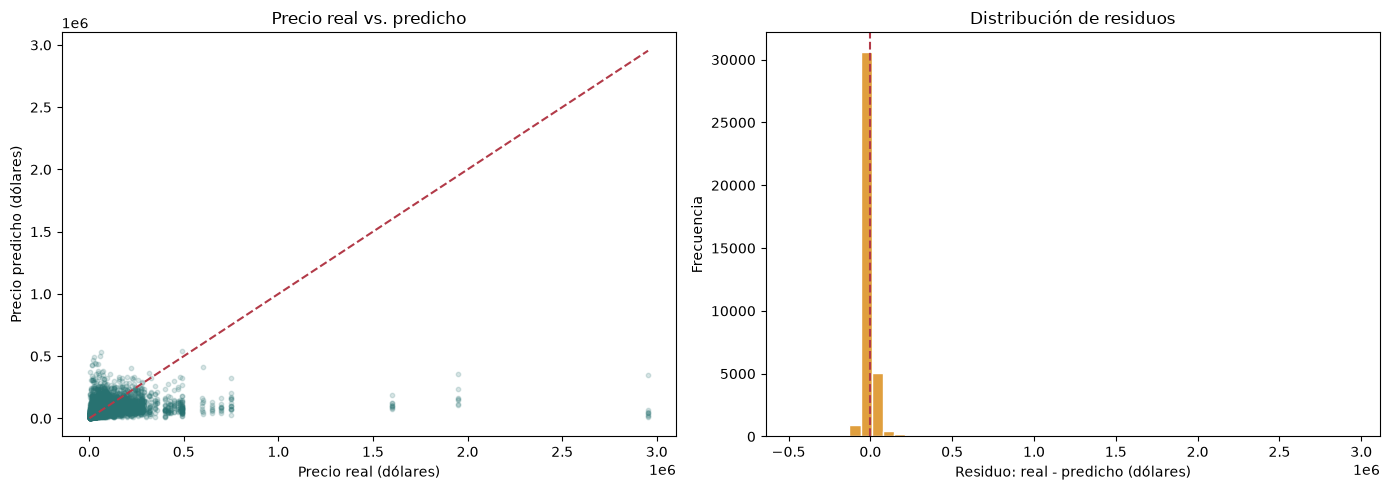

Residuo medio: -1,057 dólares
Percentiles 5 y 95 del residuo: [-44829.  34884.] dólares


In [7]:
residuals = y_test.to_numpy() - test_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, test_predictions, alpha=0.18, s=10, color="#287271")
plot_min = min(y_test.min(), test_predictions.min())
plot_max = max(y_test.max(), test_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], linestyle="--", color="#b23a48")
axes[0].set(
    title="Precio real vs. predicho",
    xlabel="Precio real (dólares)",
    ylabel="Precio predicho (dólares)",
)
axes[1].hist(residuals, bins=50, color="#e09f3e", edgecolor="white")
axes[1].axvline(0, linestyle="--", color="#b23a48")
axes[1].set(
    title="Distribución de residuos",
    xlabel="Residuo: real - predicho (dólares)",
    ylabel="Frecuencia",
)
fig.tight_layout()
plt.show()
print(f"Residuo medio: {residuals.mean():,.0f} dólares")
print(f"Percentiles 5 y 95 del residuo: {np.percentile(residuals, [5, 95]).round(0)} dólares")

La nube real-predicho debe leerse frente a la diagonal: alejarse de ella representa mayor error. El residuo medio de −1.057 dólares indica una sobreestimación promedio pequeña; sin embargo, entre los percentiles 5 y 95 hay cerca de 79.713 dólares de amplitud. Por tanto, el sesgo global está cerca de cero, pero los errores de casos individuales siguen siendo amplios, especialmente importante para precios extremos.

### Importancia de variables

El bosque permite ordenar las variables por importancia basada en reducción de impureza. La extracción de nombres viene del `ColumnTransformer`, así que aparecen los nombres de los atributos ya procesados. Esta importancia es descriptiva, no causal; con categorías ordinales y variables correlacionadas, puede repartir o sesgar la contribución. No se calcula sobre el test.

In [8]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_importance = pd.DataFrame(
    {
        "Variable transformada": feature_names,
        "Importancia": pipeline.named_steps["model"].feature_importances_,
    }
).sort_values("Importancia", ascending=False)
display(feature_importance.head(15).reset_index(drop=True).round({"Importancia": 4}))

,Variable transformada,Importancia
0,numeric__milage,0.3710
1,numeric__model_year,0.1179
2,ordinal__model,0.1134
3,ordinal__ext_col,0.0856
4,numeric__horsepower,0.0745
5,numeric__engine_liters,0.0578
6,ordinal__int_col,0.0576
7,ordinal__brand,0.0316
8,numeric__transmission_speeds,0.0313
9,numeric__cylinders,0.0132


El kilometraje es la variable dominante (importancia 0,371), seguido de año del modelo, modelo del vehículo, color exterior y potencia. Es una lectura coherente con la depreciación y las diferencias entre versiones, pero no implica causalidad. `model` y los colores usan códigos ordinales para controlar cardinalidad; el bosque puede aprovechar cortes de esos códigos, aunque su orden artificial limita la interpretación y podría mejorarse con CatBoost/LightGBM o una codificación categórica más adecuada.

## Interpretación y siguientes versiones

El modelo mejora al baseline de media en test en 5.402 dólares de RMSE (7,24%) y 8.770 dólares de MAE (30,15%); el aumento de R² es 0,1396. La mejora es consistente en las tres métricas, pero el RMSE de 69.171 dólares y el R² de 0,1396 muestran que aún quedan errores grandes y mucha variación sin explicar. La magnitud del RMSE es razonable como primera referencia frente al baseline, no como resultado final competitivo: RMSE enfatiza vehículos extremos, mientras el MAE describe mejor el error típico.

Las dificultades principales son precios muy heterogéneos, faltantes y textos de `engine`/`transmission` con formatos distintos, además de categorías de alta cardinalidad. El split aleatorio puede ser optimista si existen vehículos o anuncios repetidos. Próximos pasos: probar boosting (CatBoost/LightGBM si está disponible), búsqueda acotada de hiperparámetros solo dentro de validación cruzada, comparar `log1p(price)` mediante `TransformedTargetRegressor` reportando siempre métricas en escala original, revisar errores por rangos de precio y marcas, y usar particiones por grupo o tiempo si se dispone de identificadores/fechas que representen el uso real.

## Guardado y prueba de inferencia

Guardamos con `joblib` el pipeline completo, no solo el estimador: así quedan disponibles las extracciones y transformaciones necesarias en producción. El archivo `fase-1/modelo.joblib` corresponde a la ruta `../modelo.joblib` ejecutada desde `fase-1/notebooks/`. Después se carga y se verifica que prediga igual sobre el test; finalmente se hacen predicciones sobre tres registros crudos con las columnas originales, sin `id` ni `price`.

In [9]:
model_path = FASE_DIR / "modelo.joblib"
joblib.dump(pipeline, model_path)
loaded_pipeline = joblib.load(model_path)
loaded_test_predictions = loaded_pipeline.predict(X_test)
predictions_match = np.allclose(
    test_predictions, loaded_test_predictions, rtol=1e-12, atol=1e-8
)
assert predictions_match, "Las predicciones del pipeline cargado no coinciden."
print(f"Pipeline guardado: {model_path.resolve()}")
print(f"Tamaño del archivo: {model_path.stat().st_size / (1024 ** 2):.2f} MB")
print(f"Predicciones originales y cargadas coinciden: {predictions_match}")

raw_examples = pd.DataFrame(
    [
        {
            "brand": "BMW",
            "model": "3 Series 330i xDrive",
            "model_year": 2020,
            "milage": 35000,
            "fuel_type": "Gasoline",
            "engine": "255.0HP 2.0L 4 Cylinder Engine",
            "transmission": "8-Speed Automatic",
            "ext_col": "Black",
            "int_col": "Black",
            "accident": "None reported",
            "clean_title": "Yes",
        },
        {
            "brand": "Toyota",
            "model": "Camry SE",
            "model_year": 2018,
            "milage": 65000,
            "fuel_type": "Gasoline",
            "engine": "203.0HP 2.5L 4 Cylinder Engine",
            "transmission": "8-Speed Automatic",
            "ext_col": "Silver",
            "int_col": "Gray",
            "accident": "None reported",
            "clean_title": "Yes",
        },
        {
            "brand": "Ford",
            "model": "F-150 XLT",
            "model_year": 2021,
            "milage": 42000,
            "fuel_type": "Gasoline",
            "engine": "400.0HP 5.0L 8 Cylinder Engine",
            "transmission": "10-Speed Automatic",
            "ext_col": "Oxford White",
            "int_col": "Black",
            "accident": "At least 1 accident or damage",
            "clean_title": "Yes",
        },
    ],
    columns=X.columns,
)
raw_predictions = loaded_pipeline.predict(raw_examples)
example_results = raw_examples.copy()
example_results["price_predicho"] = raw_predictions
print("Predicciones sobre tres filas crudas (sin id ni price):")
display(example_results[["brand", "model", "model_year", "milage", "price_predicho"]].round({"price_predicho": 0}))

Pipeline guardado: C:\Users\SAMUEL\OneDrive\Documentos\ProyectosUdea\Modelos I\Proyecto-Semestral-Modelos-I\fase-1\modelo.joblib
Tamaño del archivo: 84.53 MB
Predicciones originales y cargadas coinciden: True
Predicciones sobre tres filas crudas (sin id ni price):


,brand,model,model_year,milage,price_predicho
0,BMW,3 Series 330i xDrive,2020,35000,38941.0
1,Toyota,Camry SE,2018,65000,31972.0
2,Ford,F-150 XLT,2021,42000,46955.0


La serialización se completó y el pipeline cargado reproduce las predicciones del test (`np.allclose` devuelve `True`). El archivo contiene el preprocesador y el bosque; las tres filas crudas se procesan directamente, sin construir variables derivadas a mano. Las predicciones de ejemplo son aproximadamente 38.941, 31.972 y 46.955 dólares, respectivamente.